In [1]:
import warnings
import logging
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import albumentations as A
import matplotlib.colors as mcolors
import time


from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger

import thor_terratorch_ext
from terratorch.datamodules import GenericMultiModalDataModule
from terratorch.tasks import SemanticSegmentationTask

warnings.filterwarnings("ignore", category=UserWarning, module=r"rich\.live")
warnings.filterwarnings("ignore", message=r".*does not have many workers.*")
warnings.filterwarnings("ignore", message=r".*LeafSpec.*deprecated.*")

logging.getLogger("terratorch").setLevel(logging.ERROR)
logging.getLogger("lightning").setLevel(logging.ERROR)
logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)

torch.set_float32_matmul_precision("medium")

/home/predm/venvs/thor_terratorch_ext/.venv/lib/python3.12/site-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/predm/venvs/thor_terratorch_ext/.venv/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
INFO:thor.models.patch_timm:Patching timm Attention and Block to use Alibi...
INFO:thor.models.patch_timm:Using normal attention for timm Attention


In [ ]:
s1_images = Path("/home/predm/venvs/thor_terratorch_ext/skimage_segmentation_sorted/tif_images") #/home/predm/venvs/thor_terratorch_ext/skimage_segmentation_sorted/tif_images
doppler_images = Path("/home/predm/venvs/thor_terratorch_ext/skimage_segmentation_sorted/tif_doppler") #/home/predm/venvs/thor_terratorch_ext/skimage_segmentation_sorted/tif_doppler
masks_dir = Path("/home/predm/venvs/thor_terratorch_ext/skimage_segmentation_sorted/tif_mask") #/home/predm/venvs/thor_terratorch_ext/skimage_segmentation_sorted/tif_mask
splits_dir = Path("/home/predm/venvs/thor_terratorch_ext/skimage_segmentation_sorted/splits") #/home/predm/venvs/thor_terratorch_ext/skimage_segmentation_sorted/splits

experiment = "thor_s1_doppler_notebook_run3"
log_root = Path("/home/predm/venvs/thor_terratorch_ext/notebooks/tests/terratorch_results")
default_root_dir = log_root / experiment
default_root_dir.mkdir(parents=True, exist_ok=True)

MAX_EPOCHS = 200


S1_BANDS = ["EW_HH", "EW_HV"]
DOPPLER_BANDS = ["DOPPLER"]


S1_MEANS = [141.93311161242033, 122.23673553466797]
S1_STDS = [53.95834372765628, 47.42699242760452]

DOPPLER_MEANS = [139.4596141614412]
DOPPLER_STDS = [40.77621061122129]

NUM_CLASSES = 2

In [ ]:
datamodule = GenericMultiModalDataModule(
    task="segmentation",
    batch_size=4,
    num_workers=0,
    modalities=["S1", "DOPPLER"], # "DOPPLER"
    rgb_modality="S1",
    rgb_indices=[0, 1, 1],
    train_data_root={
        "S1": str(s1_images),
        "DOPPLER": str(doppler_images),
    },
    train_label_data_root=str(masks_dir),
    val_data_root={
        "S1": str(s1_images),
        "DOPPLER": str(doppler_images),
    },
    val_label_data_root=str(masks_dir),
    test_data_root={
        "S1": str(s1_images),
        "DOPPLER": str(doppler_images),
    },
    test_label_data_root=str(masks_dir),
    train_split=str(splits_dir / "train.txt"),
    val_split=str(splits_dir / "val.txt"),
    test_split=str(splits_dir / "test.txt"),
    allow_substring_file_names=True,
    image_grep={
        "S1": "*.tif",
        "DOPPLER": "*_doppler.tif",
    },
    label_grep="*__mask.tif",
    no_label_replace=-1,
    no_data_replace=0,
    concat_bands=True,
    check_stackability=False,
    dataset_bands={
        "S1": S1_BANDS,
        "DOPPLER": DOPPLER_BANDS,
    },
    means={
        "S1": S1_MEANS,
        "DOPPLER": DOPPLER_MEANS,
    },
    stds={
        "S1": S1_STDS,
        "DOPPLER": DOPPLER_STDS,
    },
    num_classes=NUM_CLASSES,
    train_transform=[
        A.RandomCrop(height=288, width=288),
        A.D4(),
        A.pytorch.transforms.ToTensorV2(),
    ],
)

datamodule.setup("fit")

print("train dataset:", len(datamodule.train_dataset))
print("val dataset:", len(datamodule.val_dataset))
print("train batches:", len(datamodule.train_dataloader()))
print("val batches:", len(datamodule.val_dataloader()))

train dataset: 95
val dataset: 20
train batches: 23
val batches: 5


/home/predm/venvs/thor_terratorch_ext/.venv/lib/python3.12/site-packages/terratorch/datamodules/generic_multimodal_data_module.py:482: UserWarning: rgb_modality is deprecated and will be removed in a future release. Provide the modalities for plotting as keys in `rgb_indices` with the format {'<modality>': [<band indices>]}.
  warnings.warn("rgb_modality is deprecated and will be removed in a future release. Provide the modalities "


In [4]:
model_args = {
    "backbone": "MultiBackboneWrapper",
    "backbone_bands": [
        "EW_HH",
        "EW_HV",
        "DOPPLER"
    ],
    "backbone_merge_features": "concat",
    "backbone_rescale_features": "up",
    "backbone_encoders": [
        {
            "thor_v1_base": {
                "freeze_backbone": True,
                "backbone_merge_method": "concat",
                "backbone_pretrained": True,
                "backbone_input_params": {
                    "ground_covers": [2880],
                    "flexivit_patch_size_seqs": [8],
                    },
                "backbone_out_indices": [-1],
                "backbone_model_bands": [
                    "EW_HH",
                    "EW_HV",
                ],
            }
        },
        {
            "vit_small_patch16_224.dino": {
                "out_indices": [-1],
                "in_chans": 1,
                "backbone_pretrained": True,
                "backbone_dynamic_img_size": True,
                "bands": [
                    "DOPPLER"
                    ],
            }
        },
    ],
    "decoder": "FCNDecoder",
    "decoder_channels": 256,
    "num_classes": 2,
    "head_dropout": 0.1,
}
batch = next(iter(datamodule.train_dataloader()))
print("image shape:", batch["image"].shape)

print("patch size:", model_args["backbone_encoders"][0]["thor_v1_base"]["backbone_input_params"]["flexivit_patch_size_seqs"])

task = SemanticSegmentationTask(
    model_args=model_args,
    model_factory="EncoderDecoderFactory",
    loss="ce",
    lr=2e-5,
    ignore_index=-1,
    optimizer="AdamW",
    optimizer_hparams={"weight_decay": 0.05},
    scheduler="ReduceLROnPlateau",
    scheduler_hparams={
        "mode": "max",
        "factor": 0.5,
        "patience": 10,
        "threshold": 1e-4,
    },
    tiled_inference_on_validation=True,
    tiled_inference_on_testing=True,
    tiled_inference_parameters={
        "h_crop": 288,
        "h_stride": 256,
        "w_crop": 288,
        "w_stride": 256,
        "average_patches": True,
        "batch_size": 4,
    },
    freeze_backbone=False,
    freeze_decoder=False,
)

INFO:thor_terratorch_ext.models.backbones.multi_backbone_wrapper:backbone thor_v1_base bands: ['EW_HH', 'EW_HV']
/home/predm/venvs/thor_terratorch_ext/.venv/lib/python3.12/site-packages/terratorch/registry/registry.py:174: UserWarning: Overwriting input param ground_covers for model encoder with [2880]
  return self._registry[name](*constructor_args, **constructor_kwargs)
/home/predm/venvs/thor_terratorch_ext/.venv/lib/python3.12/site-packages/terratorch/registry/registry.py:174: UserWarning: Overwriting input param flexivit_patch_size_seqs for model encoder with [8]
  return self._registry[name](*constructor_args, **constructor_kwargs)
INFO:thor_terratorch_ext.models.backbones.thor_vit:Using pretrained weights for model encoder


image shape: torch.Size([4, 3, 288, 288])
patch size: [8]


INFO:httpx:HTTP Request: HEAD https://huggingface.co/FM4CS/THOR-1.0-base/resolve/main/thor_v1_vit_base.pt "HTTP/1.1 302 Found"
INFO:thor_terratorch_ext.models.backbones.thor_vit:Instantiating model encoder of type thor_vit_base_encoder_alibi_patch_size_embed_v1
INFO:thor.models.thor_vit:Found bands: ['S2:Red', 'S2:Green', 'S2:Blue', 'S2:NIR', 'S2:RE1', 'S2:RE2', 'S2:RE3', 'S2:RE4', 'S2:SWIR1', 'S2:SWIR2', 'S2:CoastAerosal', 'S2:WaterVapor', 'S1:IW-VH', 'S1:IW-VV', 'S1:EW-VH', 'S1:EW-VV', 'S1:IW-HV', 'S1:IW-HH', 'S1:EW-HV', 'S1:EW-HH', 'S3:Oa01_reflectance', 'S3:Oa02_reflectance', 'S3:Oa03_reflectance', 'S3:Oa04_reflectance', 'S3:Oa05_reflectance', 'S3:Oa06_reflectance', 'S3:Oa07_reflectance', 'S3:Oa08_reflectance', 'S3:Oa09_reflectance', 'S3:Oa10_reflectance', 'S3:Oa11_reflectance', 'S3:Oa12_reflectance', 'S3:Oa13_reflectance', 'S3:Oa14_reflectance', 'S3:Oa15_reflectance', 'S3:Oa16_reflectance', 'S3:Oa17_reflectance', 'S3:Oa18_reflectance', 'S3:Oa19_reflectance', 'S3:Oa20_reflectance',

In [5]:
logger = TensorBoardLogger(
    save_dir=str(log_root),
    name=experiment,
)

checkpoint_callback = ModelCheckpoint(
    dirpath=str(default_root_dir / "checkpoints"),
    monitor="val/mIoU",
    mode="max",
    save_top_k=1,
    save_last=True,
    filename="epoch{epoch:03d}",
    auto_insert_metric_name=False,
)

early_stopping = EarlyStopping(
    monitor="val/mIoU",
    mode="max",
    patience=30,
    min_delta=1e-4,
    check_finite=False,
    verbose=True,
)

trainer = Trainer(
    accelerator="gpu",
    strategy="auto",
    devices="auto",
    num_nodes=1,
    precision="16-mixed",
    max_epochs=MAX_EPOCHS,
    check_val_every_n_epoch=1,
    accumulate_grad_batches=1,
    log_every_n_steps=1,
    enable_checkpointing=True,
    default_root_dir=str(default_root_dir),
    logger=logger,
    callbacks=[
        checkpoint_callback,
        LearningRateMonitor(logging_interval="epoch"),
        early_stopping,
    ],
    enable_progress_bar=False,
    enable_model_summary=True,
)

trainer

INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [6]:
trainer.fit(model=task, datamodule=datamodule)

/home/predm/venvs/thor_terratorch_ext/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ PixelWiseModel   │  119 M │ train │     0 │
│ 1 │ criterion     │ CrossEntropyLoss │      0 │ train │     0 │
│ 2 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 3 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ test_metrics  │ ModuleList       │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 25.8 M                                                                                           
Non-trainable params: 94.1 M                                                                                       
Total params: 119 M                                                                                                
Total estimated model params size (MB): 479                                                                        
Modules in train mode: 645                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/home/predm/venvs/thor_terratorch_ext/.venv/lib/python3.12/site-packages/terratorch/datasets/generic_multimodal_dataset.py:532: UserWarning: No RGB modalities found (S1A_EW_GRDM_1SDH_20200101T074620_20200101T074719_030604_038191_4358). Sample keys: ['mask', 'image', 'filename', 'prediction'], Dataset rgb_indices modalities: ['S1']
  warnings.warn(f"No RGB modalities found ({suptitle}). Sample keys: {list(sample.keys())}, "
/home/predm/venvs/thor_terratorch_ext/.venv/lib/python3.12/site-packages/terratorch/datasets/generic_multimodal_dataset.py:532: UserWarning: No RGB modalities found (S1A_EW_GRDM_1SDH_20200101T074515_20200101T074619_030604_038191_EBD1). Sample keys: ['mask', 'image', 'filename', 'prediction'], Dataset rgb_indices modalities: ['S1']
  warnings.warn(f"No RGB modalities found ({suptitle}). Sample keys: {list(sample.keys())}, "
/home/predm/venvs/thor_terratorch_ext/.venv/lib/python3.12/site-packages/terratorch/datasets/generic_multimodal_dataset.py:532: UserWarning: No RG

In [7]:
print("Best checkpoint:", checkpoint_callback.best_model_path)

test_metrics = trainer.test(
    model=task,
    datamodule=datamodule,
    ckpt_path="best",
)

test_metrics

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /home/predm/venvs/thor_terratorch_ext/notebooks/tests/terratorch_results/thor_s1_doppler_notebook_run3/checkpoints/epoch051.ckpt


Best checkpoint: /home/predm/venvs/thor_terratorch_ext/notebooks/tests/terratorch_results/thor_s1_doppler_notebook_run3/checkpoints/epoch051.ckpt


INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /home/predm/venvs/thor_terratorch_ext/notebooks/tests/terratorch_results/thor_s1_doppler_notebook_run3/checkpoints/epoch051.ckpt


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/Accuracy       │    0.9533538818359375     │
│    test/Boundary_mIoU     │    0.06311678141355515    │
│   test/Class_Accuracy_0   │    0.9670634865760803     │
│   test/Class_Accuracy_1   │    0.9396443367004395     │
│       test/F1_Score       │    0.9534556269645691     │
│        test/IoU_0         │    0.9129578471183777     │
│        test/IoU_1         │     0.909148633480072     │
│    test/Pixel_Accuracy    │     0.953478991985321     │
│         test/loss         │    0.13186916708946228    │
│         test/mIoU         │    0.9110532402992249     │
│      test/mIoU_Micro      │    0.9110940098762512     │
└───────────────────────────┴───────────────────────────┘

[{'test/loss': 0.13186916708946228,
  'test/Accuracy': 0.9533538818359375,
  'test/Boundary_mIoU': 0.06311678141355515,
  'test/Class_Accuracy_0': 0.9670634865760803,
  'test/Class_Accuracy_1': 0.9396443367004395,
  'test/F1_Score': 0.9534556269645691,
  'test/IoU_0': 0.9129578471183777,
  'test/IoU_1': 0.909148633480072,
  'test/Pixel_Accuracy': 0.953478991985321,
  'test/mIoU': 0.9110532402992249,
  'test/mIoU_Micro': 0.9110940098762512}]

In [8]:
best_ckpt = checkpoint_callback.best_model_path
ckpt = torch.load(best_ckpt, map_location="cpu")
task.load_state_dict(ckpt["state_dict"], strict=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
task.to(device)
task.eval()

print("Loaded best checkpoint:", best_ckpt)

Loaded best checkpoint: /home/predm/venvs/thor_terratorch_ext/notebooks/tests/terratorch_results/thor_s1_doppler_notebook_run3/checkpoints/epoch051.ckpt


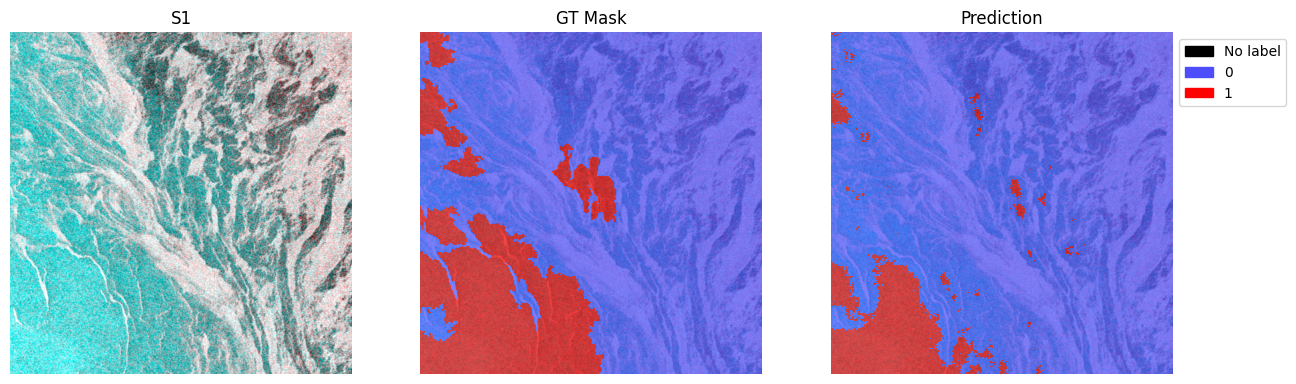

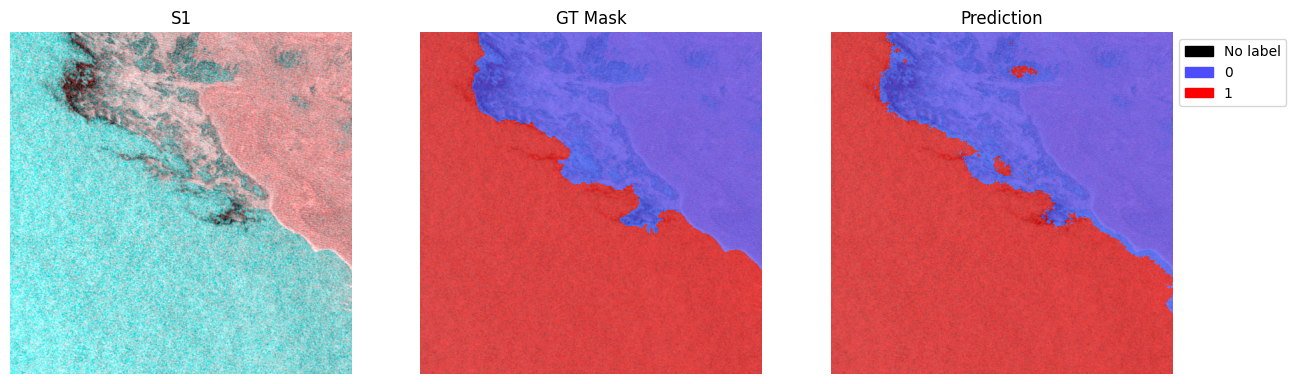

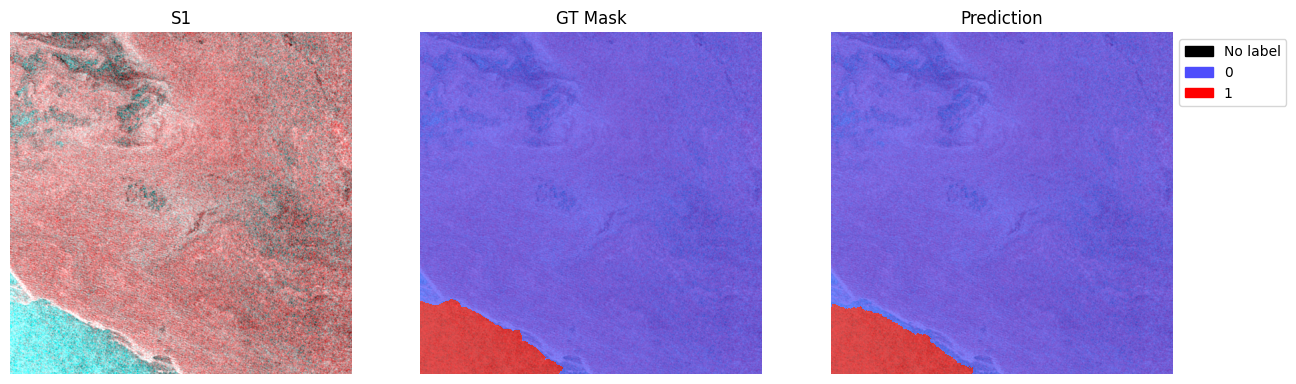

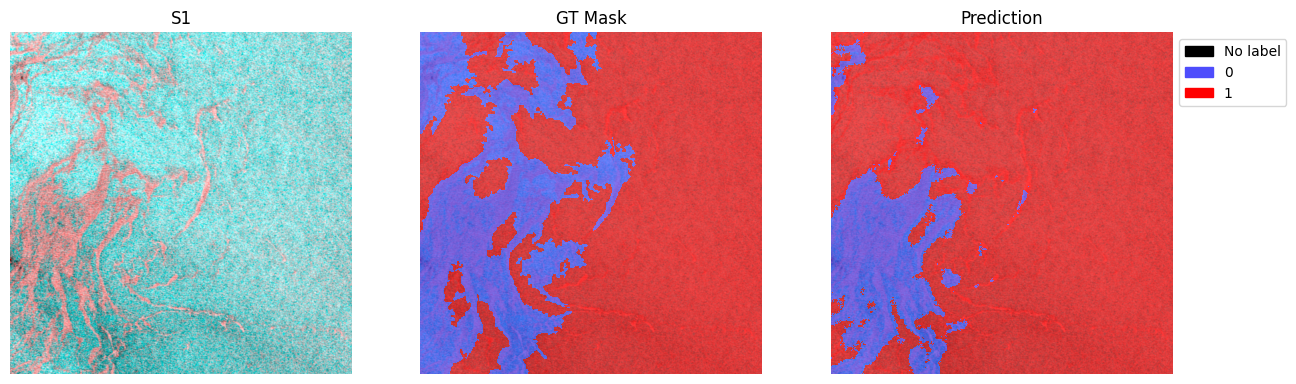

In [ ]:
datamodule.setup("test")
test_dataset = datamodule.test_dataset
test_loader = datamodule.test_dataloader()
# Use the trained task for inference and visualization
task.eval()


# Get a batch from the test dataloader
datamodule.setup("test")
test_loader = datamodule.test_dataloader()

with torch.no_grad():
    batch_idx = 1

    for j, batch in enumerate(test_loader):
        if j == batch_idx:
            break

    batch = datamodule.aug(batch)
    images = batch["image"].to(task.device)
    masks = batch["mask"].cpu().numpy()

    outputs = task.handle_full_or_tiled_inference(
    images,
    use_tiled_inference=True,
    )
    preds = torch.argmax(outputs.output, dim=1).cpu().numpy()

num_examples = min(6, len(preds))
for i in range(0, num_examples):
    sample = {
    "S1": batch["image"][i][:2].cpu(),
    "mask": batch["mask"][i],
    "prediction": preds[i],
}
    test_dataset.plot(sample)
    